# Resource estimation for amplitude amplification: from NISQ to FTQC

This tutorial builds an **amplitude amplification** (Grover search) circuit
with [qsub](../3_qsub/basics.ipynb) and asks a single question at increasing
levels of hardware realism: *what does it take to run it?*

1. **Problem statement** — the circuit, and its architecture-independent
   logical cost.
2. **NISQ era** — resource estimation with QURI VM device models
   parameterized by the published IBM and IonQ roadmaps: how large an
   instance can each vendor's machines run, year by year?
3. **The error-corrected era** — the QURI SDK's estimation tools for
   partially fault-tolerant (**STAR**) and fully fault-tolerant
   (**QURATION** / pyqret) architectures, and what they do.
4. **FTQC estimation** — instruction-set-level compilation to the
   surface-code lattice-surgery architecture `SC_LS_FIXED_V0`, including
   physical-qubit counts, execution time and architecture scans.
5. **Pre-FTQC estimation** — the same instances on the STAR early-FTQC
   architecture.
6. **The combined picture** — STAR and FTQC feasibility added onto the NISQ
   roadmap timeline.
7. **Time to solution** — folding circuit latency, fidelity and repetitions
   into a single practicality metric.

If quri-parts with the qsub and qret extras is not installed, install it with:

```
%pip install "quri-parts[qsub,qret]"
```

## Problem statement: amplitude amplification

Given a state-preparation unitary $A$ and an oracle that marks "good" states,
amplitude amplification repeats the Grover iterate

$$ G = A S_0 A^{\dagger} S_f $$

where $S_f$ flips the phase of the marked states and $S_0$ flips the phase of
$|0\rangle^{\otimes n}$. For a single marked state out of $N = 2^n$, starting
from the uniform superposition $A = H^{\otimes n}$, the success probability is
maximized after $k \approx \frac{\pi}{4}\sqrt{N}$ iterations.

In this tutorial the oracle marks one chosen basis state, so both $S_f$ and
$S_0$ are **multi-controlled-Z** gates (up to conjugation by $X$ gates). The
resource cost is therefore dominated by two $(n-1)$-controlled Z gates per
iteration, whose Toffoli/T-count grows linearly with $n$ — combined with the
$\sqrt{N}$ iteration count this gives a clean, predictable scaling to study.

One caveat on the benchmark character: an oracle that marks a single *known*
basis state is classically trivial — the marked string can be read off the
circuit, so nothing in this family is classically hard at any $n$. Classical
comparisons made later follow the standard black-box query-model convention,
and the resource estimates measure the cost of the amplitude-amplification
*machinery* itself, which is unchanged if this toy oracle is swapped for a
genuinely hard one.

The whole algorithm is expressed as a single parametric qsub operator
`GroverAA(qubit_count, marked_state, iterations)`. Both reflections reuse one
multi-controlled-Z, conjugated by `X` on the qubits whose target bit is 0.

In [1]:
from collections.abc import Sequence

from quri_parts.qsub.lib import std
from quri_parts.qsub.opsub import ParamUnitarySubDef, param_opsub
from quri_parts.qsub.register import DEFAULT_QNAME, QRegSpec
from quri_parts.qsub.sub import SubBuilder


class _GroverAA(ParamUnitarySubDef[int, int, int]):
    """Amplitude amplification with a marked-state (multi-controlled-Z) oracle.

    Parameters are ``(qubit_count, marked_state, iterations)``: prepare the
    uniform superposition ``A = H^n``, then apply ``iterations`` Grover
    iterates ``G = A S_0 A^dagger S_f``.
    """

    name = "GroverAA"

    def qubit_count_fn(
        self, qubit_count: int, marked_state: int, iterations: int
    ) -> int:
        return qubit_count

    def qregs_fn(
        self, qubit_count: int, marked_state: int, iterations: int
    ) -> Sequence[QRegSpec]:
        return (QRegSpec(DEFAULT_QNAME, qubit_count),)

    def sub(
        self,
        builder: SubBuilder,
        qubit_count: int,
        marked_state: int,
        iterations: int,
    ) -> None:
        qubits = builder.qubits
        mcz = std.MCZ(qubit_count - 1)

        def reflection(marked: int) -> None:
            flipped = [q for i, q in enumerate(qubits) if not (marked >> i) & 1]
            for q in flipped:
                builder.add_op(std.X, (q,))
            builder.add_op(mcz, tuple(qubits))
            for q in flipped:
                builder.add_op(std.X, (q,))

        for q in qubits:
            builder.add_op(std.H, (q,))
        for _ in range(iterations):
            # Oracle S_f: phase-flip the marked basis state.
            reflection(marked_state)
            # Diffusion A S_0 A^dagger: reflect about the uniform superposition.
            for q in qubits:
                builder.add_op(std.H, (q,))
            reflection(0)
            for q in qubits:
                builder.add_op(std.H, (q,))


GroverAA, GroverAASub = param_opsub(_GroverAA)

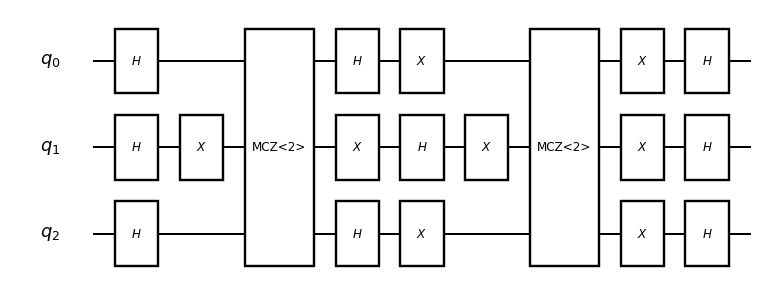

In [2]:
from quri_parts.qsub.visualize import draw

draw(GroverAA(3, 0b101, 1))

### Logical resource counts (architecture independent)

qsub compiles the operator to the `AllBasicSet` primitive gate set and counts
gates and qubits. The multi-controlled-Z decomposition introduces auxiliary
qubits, which we include in the total. These logical numbers are the input
that every architecture-specific estimate below builds on.

In [3]:
from math import floor, pi, sqrt

import pandas as pd
from quri_parts.qsub.compile import compile as compile_qsub
from quri_parts.qsub.eval import AuxQubitCountEvaluatorHooks, GateCountEvaluatorHooks
from quri_parts.qsub.evaluate import Evaluator
from quri_parts.qsub.primitive import AllBasicSet


def optimal_iterations(qubit_count: int) -> int:
    """Optimal Grover iteration count for one marked state out of 2**n."""
    return max(1, floor(pi / 4 * sqrt(2**qubit_count)))


def logical_resources(
    qubit_count: int, marked_state: int, iterations: int
) -> dict[str, int]:
    """Architecture-independent qubit and gate counts evaluated by qsub."""
    op = GroverAA(qubit_count, marked_state, iterations)
    compiled = compile_qsub(op, AllBasicSet)
    aux_qubits: int = Evaluator(AuxQubitCountEvaluatorHooks()).run(compiled)
    gate_counts = Evaluator(GateCountEvaluatorHooks(AllBasicSet)).run(compiled)
    resources: dict[str, int] = {
        "n": qubit_count,
        "iterations": iterations,
        "qubits (incl. aux)": len(compiled.qubits) + aux_qubits,
    }
    for (_, gate_name), count in gate_counts.items():
        resources[gate_name] = count
    return resources


QUBIT_RANGE = range(3, 8)

logical_df = pd.DataFrame(
    [logical_resources(n, (1 << n) - 2, optimal_iterations(n)) for n in QUBIT_RANGE]
)
logical_df = logical_df.fillna(0).astype(int).set_index("n")
logical_df

,iterations,qubits (incl. aux),H,X,Toffoli,CZ
n,,,,,,
3,2,3,23,16,4,0
4,3,6,28,30,24,6
5,4,8,45,48,48,8
6,6,10,78,84,96,12
7,8,12,119,128,160,16


## NISQ era: estimation against the IBM and IonQ roadmaps

Before any error-corrected machine exists, what can the hardware on vendor
roadmaps do with this circuit? QURI VM provides NISQ device models —
`nisq_spcond_lattice` (superconducting, square-lattice connectivity, matching
IBM's platform) and `nisq_iontrap_device` (trapped ion, all-to-all
connectivity, matching IonQ's) — which we parameterize with the published
roadmaps and use to estimate whole-circuit fidelity.

Roadmap milestones used (public vendor announcements as of mid-2026):

| Vendor | Year | System | Qubits | Basis of error assumption |
|---|---|---|---|---|
| IBM | 2025 | Nighthawk | 120 | 5,000 reliably executable 2Q gates |
| IBM | 2026 | Nighthawk (3 modules) | 360 | 7,500 gates |
| IBM | 2027 | Nighthawk (Cockatoo era) | 360 | 10,000 gates |
| IBM | 2028 | Nighthawk (final) | 360 | 15,000 gates |
| IBM | **2029** | **Starling (FTQC)** | **200 logical** | 100M logical gates |
| IBM | 2033 | Blue Jay (FTQC) | 2,000 logical | 1B logical gates |
| IonQ | 2024 | Forte | 36 | 99.35% 2Q fidelity (measured) |
| IonQ | 2025 | Tempo | 100 | 99.9% 2Q fidelity |
| IonQ | 2026 | 256-qubit system | 256 | 99.99% 2Q fidelity (demonstrated 2025) |
| IonQ | **2027** | **10k physical (FTQC)** | **800 logical** | error-corrected |
| IonQ | 2030 | 2M physical (FTQC) | 80,000 logical (top of stated range) | error-corrected |

Assumptions, to be taken as rough sketches rather than vendor claims:

* For IBM's NISQ years we translate the "reliably executable gates" target $G$
  into an effective two-qubit error per gate $\approx 1/G$; IonQ quotes gate
  fidelities directly.
* Single-qubit error is taken as 1/10 of the two-qubit error, measurement
  error as a small multiple of it; gate times are held at typical published
  values per platform and not scaled over the years. Coherence-time (T1/T2)
  effects are not part of the VM gate-error model.
* These choices are generous to the hardware: the implied readout errors
  (5–10× the 2Q error) are better than demonstrated readout on either
  platform (~10⁻³–10⁻²), idle errors are absent, and IonQ's 99.99% figure is
  a two-ion R&D prototype result intended to underpin the 2026 systems — not
  a measured system-wide fidelity. Feasibility verdicts are best-case
  readings. IBM's "3 modules / 360 qubits" rows are likewise our modular
  reading of the roadmap (immaterial here — no instance uses more than 12
  qubits).
* The square-lattice model routes the circuit on the smallest sufficient
  lattice — a best-case placement; real compilation on a larger chip adds
  SWAP overhead. IonQ's all-to-all connectivity needs no routing.
* An instance counts as *feasible* when the estimated whole-circuit fidelity
  is at least 2/3. IBM entries are scanned up to $n = 6$: the routing
  analysis becomes slow beyond that and the fidelity there is already
  indistinguishable from zero.
* The scan range ends at $n = 7$ for two *distinct* reasons, one physical
  and one computational. **Hardware limit**: fidelity decays exponentially
  with gate count, so nearly every milestone's feasibility verdict is settled
  well inside the scanned range (fidelities are ≈ 0 by $n = 6$–$7$). The one
  exception is IonQ's 99.99%-fidelity 2026 system, which remains above the
  threshold at the scan edge and would stay feasible for roughly one more
  step ($n \approx 8$) before its fidelity crosses 2/3. **Analysis limit**:
  separately, each Grover step count doubles per $+2$ in $n$
  ($k \approx \frac{\pi}{4} 2^{n/2}$) and the square-lattice routing
  analysis takes minutes per entry beyond $n = 7$ — a cost of the estimation
  tooling, not a property of the hardware. The error-corrected sections
  below continue to larger $n$, where estimation stays cheap.
* The FTQC-era milestones (bold rows) are not NISQ machines; they re-enter
  the picture in the final section, compared at the logical level.

Sources: [IBM quantum roadmap](https://www.ibm.com/roadmaps/quantum/),
[IBM large-scale FTQC blog](https://www.ibm.com/quantum/blog/large-scale-ftqc),
[IonQ roadmap](https://www.ionq.com/roadmap),
[IonQ accelerated roadmap](https://www.ionq.com/blog/ionqs-accelerated-roadmap-turning-quantum-ambition-into-reality).

In [4]:
from dataclasses import dataclass
from math import ceil
from typing import Any

from quri_parts.backend.devices import nisq_iontrap_device, nisq_spcond_lattice
from quri_parts.backend.units import TimeUnit, TimeValue
from quri_parts.circuit import NonParametricQuantumCircuit
from quri_parts.circuit.topology import SquareLattice
from quri_parts.qsub.eval import QURIPartsEvaluatorHooks
from quri_vm.vm import VM
from quri_vm.vm_backend import AnalyzeResult


@dataclass(frozen=True)
class RoadmapEntry:
    """One NISQ milestone of a vendor roadmap."""

    vendor: str
    year: int
    system: str
    qubits: int
    error_2q: float


NISQ_ROADMAP: tuple[RoadmapEntry, ...] = (
    RoadmapEntry("IBM", 2025, "Nighthawk", 120, 1 / 5000),
    RoadmapEntry("IBM", 2026, "Nighthawk (3 modules)", 360, 1 / 7500),
    RoadmapEntry("IBM", 2027, "Nighthawk (Cockatoo era)", 360, 1 / 10000),
    RoadmapEntry("IBM", 2028, "Nighthawk (final)", 360, 1 / 15000),
    RoadmapEntry("IonQ", 2024, "Forte", 36, 6.5e-3),
    RoadmapEntry("IonQ", 2025, "Tempo", 100, 1.0e-3),
    RoadmapEntry("IonQ", 2026, "256-qubit system", 256, 1.0e-4),
)


def aa_quri_parts_circuit(qubit_count: int) -> NonParametricQuantumCircuit:
    """Export one AA instance as a QURI Parts circuit for VM analysis."""
    op = GroverAA(qubit_count, (1 << qubit_count) - 2, optimal_iterations(qubit_count))
    return Evaluator(QURIPartsEvaluatorHooks()).run(compile_qsub(op, AllBasicSet))


AA_CIRCUITS: dict[int, NonParametricQuantumCircuit] = {
    n: aa_quri_parts_circuit(n) for n in QUBIT_RANGE
}

# IBM instances above n=6 are skipped: the lattice-routing analysis is slow
# there and the fidelity is already indistinguishable from zero.
IBM_SCAN_LIMIT = 6


def roadmap_vm(entry: RoadmapEntry, circuit_qubits: int) -> VM:
    """Build a VM for a roadmap milestone using the vendor's device model.

    The square-lattice model places the circuit on the smallest sufficient
    lattice (best-case placement).
    """
    if entry.vendor == "IBM":
        side = max(2, ceil(sqrt(circuit_qubits)))
        prop = nisq_spcond_lattice.generate_device_property(
            lattice=SquareLattice(side, side),
            native_gates_1q=("RZ", "SqrtX", "X"),
            native_gates_2q=("CZ",),
            gate_error_1q=entry.error_2q / 10,
            gate_error_2q=entry.error_2q,
            gate_error_meas=entry.error_2q * 10,
            gate_time_1q=TimeValue(value=60, unit=TimeUnit.NANOSECOND),
            gate_time_2q=TimeValue(value=100, unit=TimeUnit.NANOSECOND),
            gate_time_meas=TimeValue(value=1, unit=TimeUnit.MICROSECOND),
        )
    else:
        prop = nisq_iontrap_device.generate_device_property(
            qubit_count=entry.qubits,
            native_gates_1q=("RX", "RY", "RZ"),
            native_gates_2q=("CNOT",),
            gate_error_1q=entry.error_2q / 10,
            gate_error_2q=entry.error_2q,
            gate_error_meas=entry.error_2q * 5,
            gate_time_1q=TimeValue(value=135, unit=TimeUnit.MICROSECOND),
            gate_time_2q=TimeValue(value=600, unit=TimeUnit.MICROSECOND),
            gate_time_meas=TimeValue(value=300, unit=TimeUnit.MICROSECOND),
        )
    return VM.from_device_prop(prop)


FEASIBILITY_THRESHOLD = 2 / 3

# Full analysis results, keyed by (vendor, year, n); reused later for the
# time-to-solution estimates.
ANALYZE_RESULTS: dict[tuple[str, int, int], AnalyzeResult] = {}

rows: list[dict[str, Any]] = []
for entry in NISQ_ROADMAP:
    fidelities: dict[str, float] = {}
    for n in QUBIT_RANGE:
        if entry.vendor == "IBM" and n > IBM_SCAN_LIMIT:
            continue
        circuit = AA_CIRCUITS[n]
        result = roadmap_vm(entry, circuit.qubit_count).analyze(circuit)
        ANALYZE_RESULTS[(entry.vendor, entry.year, n)] = result
        fidelities[f"fidelity (n={n})"] = result.fidelity
    feasible = [
        n
        for n in QUBIT_RANGE
        if fidelities.get(f"fidelity (n={n})", 0.0) >= FEASIBILITY_THRESHOLD
    ]
    rows.append(
        {
            "vendor": entry.vendor,
            "year": entry.year,
            "system": entry.system,
            "2Q error": entry.error_2q,
            "max feasible n": max(feasible) if feasible else 0,
            **fidelities,
        }
    )

roadmap_df = pd.DataFrame(rows).set_index(["vendor", "year"])
roadmap_df.round(4)

system  2Q error  max feasible n  \
vendor year                                                       
IBM    2025                 Nighthawk    0.0002               4   
       2026     Nighthawk (3 modules)    0.0001               4   
       2027  Nighthawk (Cockatoo era)    0.0001               4   
       2028         Nighthawk (final)    0.0001               5   
IonQ   2024                     Forte    0.0065               3   
       2025                     Tempo    0.0010               5   
       2026          256-qubit system    0.0001               7   

             fidelity (n=3)  fidelity (n=4)  fidelity (n=5)  fidelity (n=6)  \
vendor year                                                                   
IBM    2025          0.9612          0.7874          0.3701          0.1374   
       2026          0.9740          0.8527          0.5155          0.2662   
       2027          0.9804          0.8874          0.6084          0.3707   
       2028          0.9869          0.9234          0.7180          0.5160   
IonQ   2024          0.7982          0.2948          0.0922          0.0090   
       2025          0.9660          0.8290          0.6935          0.4854   
       2026          0.9965          0.9814          0.9641          0.9303   

             fidelity (n=7)  
vendor year                  
IBM    2025             NaN  
       2026             NaN  
       2027             NaN  
       2028             NaN  
IonQ   2024          0.0004  
       2025          0.3026  
       2026          0.8874

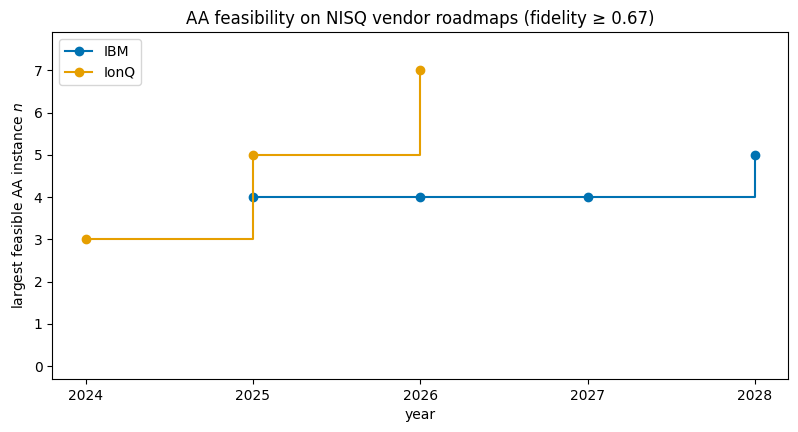

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

COLOR_BLUE = "#0072B2"
COLOR_ORANGE = "#E69F00"
COLOR_GREEN = "#009E73"


def plot_feasibility_timeline(ax: plt.Axes) -> None:
    """Step plot of the largest feasible AA instance per vendor and year."""
    for vendor, color in (("IBM", COLOR_BLUE), ("IonQ", COLOR_ORANGE)):
        milestones = roadmap_df.xs(vendor).sort_index()
        ax.step(
            milestones.index,
            milestones["max feasible n"],
            where="post",
            marker="o",
            color=color,
            label=vendor,
        )
    ax.set_xlabel("year")
    ax.set_ylabel("largest feasible AA instance $n$")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))


fig, ax = plt.subplots(figsize=(9.5, 4.5))
plot_feasibility_timeline(ax)
ax.set_ylim(-0.3, 7.9)
ax.set_title(f"AA feasibility on NISQ vendor roadmaps (fidelity ≥ {2 / 3:.2f})")
ax.legend(loc="upper left")
plt.show()

Reading the NISQ results:

* **IBM (superconducting)**: the effective error rates implied by the
  Nighthawk gate-count targets keep AA feasibility at $n \approx 4$–$5$
  through 2028. The square-lattice connectivity is a real cost here: SWAP
  routing multiplies the two-qubit gate count of the multi-controlled-Z
  ladders. In exchange, gate speed gives ~µs-scale shots, orders of magnitude
  faster than trapped ions.
* **IonQ (trapped ion)**: all-to-all connectivity means no routing overhead,
  and the quoted fidelities improve fast — at the demonstrated 99.99%
  two-qubit fidelity targeted for the 2026 256-qubit system, *every instance
  in this notebook* ($n \le 7$, fidelity ≈ 0.89) becomes feasible even
  without error correction, albeit with ~0.1 s-scale shots.

Fidelity per shot is not the whole story, though: it decays exponentially
with circuit size, so NISQ feasibility ends abruptly just beyond the sizes
scanned here. Scaling further requires error correction — the following
sections introduce the QURI SDK's tools for that era and then add their
verdicts to this timeline.

## Tools for the error-corrected era

The QURI SDK offers resource estimation at three levels. The **logical
level** (qsub) opened this notebook. For error-corrected machines there are
two complementary tools:

### Pre-FTQC: the STAR architecture (QURI VM)

**STAR** ([arXiv:2303.13181](https://arxiv.org/abs/2303.13181)) is an
*early fault-tolerant* architecture: Clifford operations are protected by the
surface code, while arbitrary $RZ(\theta)$ rotations are injected through
analog ancilla states — cheaper than magic-state distillation but with a
residual, non-correctable error per rotation. It targets the
$\sim 10^4$-physical-qubit era, between NISQ and full FTQC. QURI VM models
it via `quri_parts.backend.devices.star_device` and reports circuit fidelity
and latency through `VM.analyze`. (Two sibling device models,
`clifford_t_device` and `abstract_ftqc_device`, cover standard Clifford+T
FTQC at the same gate-level granularity.)

### FTQC: QURATION / pyqret — instruction-set-level compilation

**QURATION** is QunaSys's FTQC resource-estimation compiler, used through its
Python bindings `pyqret`. Instead of applying an error model to a gate list,
it *compiles* the program down to the instruction set of a concrete
error-corrected machine — placing logical qubits as surface-code patches on a
tile grid, routing lattice-surgery operations, and scheduling T gates against
magic-state production — so the resource figures come from an actual
schedule. Its compile target `SC_LS_FIXED_V0` (surface code, lattice surgery,
fixed layout) supports several machine types:

| Machine type | Description | Status |
|---|---|---|
| `Dim2` | planar (2D) grid of surface-code patches | supported (chosen by `auto` for planar topologies) |
| `Dim3` | 3D-connected grid | supported |
| `DistributedDim2` | multiple 2D chips connected by entanglement links | supported |
| `DistributedDim3` | multiple 3D chips | declared, currently unsupported |

A concrete architecture instance is assembled from a **topology** YAML (grid
size and magic-state-factory placement), **magic-state supply** parameters,
and **hardware quality** parameters, all passed via `ScLsFixedV0Option`:

| Parameter | Meaning |
|---|---|
| `topology` | path to the topology YAML (grid size, factory placement) |
| `magic_generation_period` | code cycles per magic state per factory (default 15) |
| `prob_magic_state_creation` | success probability of each production attempt |
| `maximum_magic_state_stock` | magic-state buffer capacity (default 10000) |
| `use_magic_state_cultivation` | use cultivation instead of distillation |
| `physical_error_rate` | error rate of physical operations |
| `code_cycle_time_sec` | wall-clock duration of one surface-code cycle |
| `reaction_time` | classical feedback latency in cycles (default 1) |
| `allowed_failure_prob` | total logical-failure budget of the computation |
| `drop_rate` | the error-suppression factor of the QEC model: the factor by which the logical error rate drops per **two-step** code-distance increment $d \to d+2$ (verified empirically — the solved distance responds as $p_L \propto p \cdot \text{drop\_rate}^{(d-1)/2}$). The default 0 admits no solution, so the QEC pass reports zeros. Our value 0.1 corresponds to suppression $\Lambda = 10$, the textbook surface-code scaling at $p/p_{\text{th}} = 0.1$; note that demonstrated hardware is at $\Lambda \approx 2$ (Google Willow, 2024), so this is a projection, not a demonstrated figure |
| `entanglement_generation_period`, `maximum_entangled_state_stock` | entanglement supply for the `Distributed*` machine types |

The estimation flow is: convert the qsub operator to QURATION IR
(`quri_parts.qret.convert_qsub.create_module_from_qsub_op`), generate a
topology (`quri_parts.qret.topology_utils.write_generated_topology`), compile
with `pyqret.backend.Compiler`, and read the figures from the compile info.
Two practical notes, reflected in the helper below:

* The mapper needs free tiles for routing. If placement fails
  (`Failed to find place to map qubits`), regenerate the topology with a
  larger `slack_factor` and retry.
* The pass `sc_ls_fixed_v0::calc_info_with_qec_resource_estimation` is not in
  the default pass list; add it (together with a nonzero `drop_rate`, see the
  table above) to obtain code distance, physical-qubit count and execution
  time.

## FTQC estimation with QURATION (pyqret)

In [6]:
from pathlib import Path

import pyqret.backend as backend
from quri_parts.qret.convert_qsub import create_module_from_qsub_op
from quri_parts.qret.topology_utils import write_generated_topology

ARTIFACT_DIR = Path("aa")
ARTIFACT_DIR.mkdir(exist_ok=True)

SLACK_FACTORS: tuple[float, ...] = (1.5, 2.0, 3.0, 4.0, 6.0, 9.0, 12.0)


def estimate_sc_ls_fixed_v0(
    qubit_count: int,
    marked_state: int,
    iterations: int,
    *,
    magic_factory_count: int = 4,
    physical_error_rate: float = 1e-3,
    code_cycle_time_sec: float = 1e-6,
    allowed_failure_prob: float = 1e-2,
    drop_rate: float = 0.1,
    slack_factors: Sequence[float] = SLACK_FACTORS,
) -> dict[str, Any]:
    """Compile one AA instance to SC_LS_FIXED_V0 and collect resource figures.

    The topology is regenerated with increasing ``slack_factor`` until qubit
    placement succeeds.
    """
    op = GroverAA(qubit_count, marked_state, iterations)
    compiled = compile_qsub(op, AllBasicSet)
    aux_qubits: int = Evaluator(AuxQubitCountEvaluatorHooks()).run(compiled)
    required_qubits = len(compiled.qubits) + aux_qubits

    module = create_module_from_qsub_op(entry_op=op)
    circuit = module.get_circuit(op.id.to_str())
    module.dump(str(ARTIFACT_DIR / f"aa_ir_n{qubit_count}.json"))

    topology_path = (
        ARTIFACT_DIR / f"topology_n{qubit_count}_m{magic_factory_count}.yaml"
    )
    last_error: RuntimeError | None = None
    for slack_factor in slack_factors:
        write_generated_topology(
            topology_path,
            required_qubits,
            slack_factor=slack_factor,
            magic_factory_count=magic_factory_count,
        )
        option = backend.CompileOption(
            backend.OptLevel.O0,
            sc_ls_fixed_v0_option=backend.ScLsFixedV0Option(
                topology=str(topology_path),
                physical_error_rate=physical_error_rate,
                code_cycle_time_sec=code_cycle_time_sec,
                allowed_failure_prob=allowed_failure_prob,
                drop_rate=drop_rate,
            ),
        )
        compiler = backend.Compiler(option)
        compiler.add_pass("sc_ls_fixed_v0::calc_info_with_qec_resource_estimation")
        try:
            compiler.compile(circuit)
        except RuntimeError as error:
            last_error = error
            continue
        info = compiler.get_compile_info()
        return {
            "n": qubit_count,
            "iterations": iterations,
            "logical qubits": required_qubits,
            "slack factor": slack_factor,
            "code distance": info.code_distance,
            "physical qubits": info.num_physical_qubits,
            "chip cells": info.chip_cell_count,
            "ISA gate count": info.gate_count,
            "ISA gate depth": info.gate_depth,
            "runtime (cycles)": info.runtime,
            "execution time (s)": info.execution_time_sec,
            "magic states": info.magic_state_consumption_count,
            "qubit volume": info.qubit_volume,
        }
    raise RuntimeError(
        f"Mapping failed for n={qubit_count} at all slack factors"
    ) from last_error


estimate_sc_ls_fixed_v0(4, 0b1010, optimal_iterations(4))

{'n': 4,
 'iterations': 3,
 'logical qubits': 6,
 'slack factor': 3.0,
 'code distance': 7,
 'physical qubits': 2058,
 'chip cells': 21,
 'ISA gate count': 908,
 'ISA gate depth': 456,
 'runtime (cycles)': 646,
 'execution time (s)': 0.004522,
 'magic states': 168,
 'qubit volume': 5316}

The full compile information (including per-instruction gate counts,
magic-state consumption over time and chip-cell utilization) is available via
`compiler.get_compile_info().to_markdown()` or `.to_json()`.

### Scaling with problem size

We now scan the number of search qubits $n$, using the optimal iteration
count for each size. Unlike the NISQ analysis, QURATION stays fast well past
$n = 7$ (the gate count roughly doubles per $+2$ in $n$, and compilation time
stays within seconds through $n = 14$), so the FTQC scan continues to $n = 14$ — 100 Grover iterations and
~170k logical gates.

In [7]:
FTQC_QUBIT_RANGE = range(3, 15)

quration_df = pd.DataFrame(
    [
        estimate_sc_ls_fixed_v0(n, (1 << n) - 2, optimal_iterations(n))
        for n in FTQC_QUBIT_RANGE
    ]
).set_index("n")
quration_df

,iterations,logical qubits,slack factor,code distance,physical qubits,chip cells,ISA gate count,ISA gate depth,runtime (cycles),execution time (s),magic states,qubit volume
n,,,,,,,,,,,,
3,2,3,6.0,5,1050,21,173,80,121,0.000605,28,653
4,3,6,3.0,7,2058,21,908,456,646,0.004522,168,5316
5,4,8,6.0,9,8424,52,1777,896,1277,0.011493,336,14908
6,6,10,4.0,9,7290,45,3510,1776,2533,0.022797,672,34468
7,8,12,4.0,9,8424,52,5811,2944,4216,0.037944,1120,65063
8,12,14,4.0,11,14520,60,10408,5280,7576,0.083336,2016,136059
9,17,16,4.0,11,16456,68,17147,8704,12512,0.137632,3332,259836
10,25,18,4.0,11,18634,77,28750,14600,21017,0.231187,5600,486452
11,35,20,4.0,11,20812,86,45205,22960,33092,0.364012,8820,822817


Two structural effects are visible in the table. The physical-qubit count does
not grow monotonically with $n$: it is the product of the tile grid actually
used — the smallest one (over the `slack factor` retries) where placement
succeeded — and the patch size set by the code distance. And the **code
distance itself climbs** across the range (9 → 11 → 13): a longer computation
offers more opportunities for a logical error, so keeping the total failure
probability inside `allowed_failure_prob` demands a larger code distance —
the same feedback between runtime and distance seen in the factory scan
below.

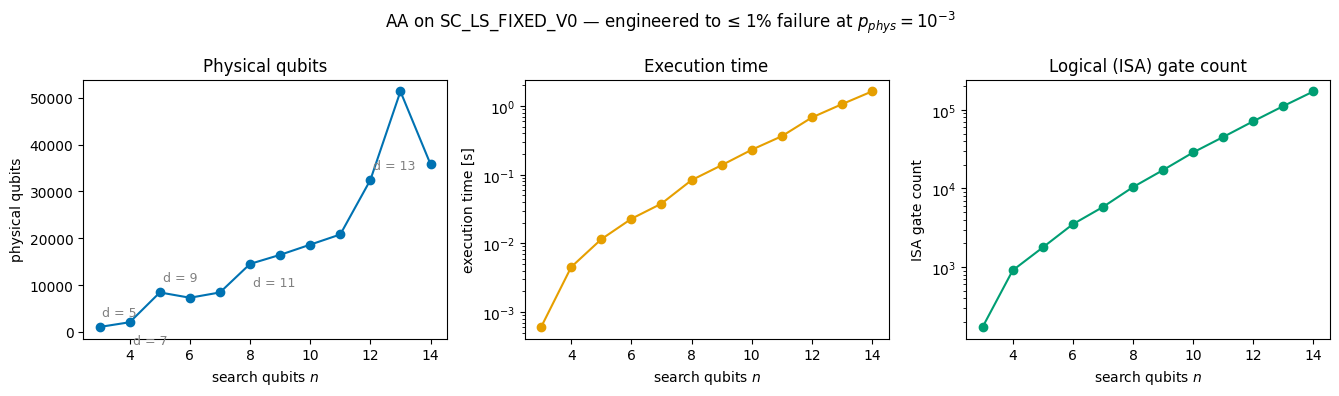

In [8]:
fig, (ax_qubits, ax_time, ax_gates) = plt.subplots(1, 3, figsize=(13.5, 4))

ax_qubits.plot(
    quration_df.index,
    quration_df["physical qubits"],
    marker="o",
    color=COLOR_BLUE,
)
ax_qubits.set_xlabel("search qubits $n$")
ax_qubits.set_ylabel("physical qubits")
ax_qubits.set_title("Physical qubits")

previous_distance = 0
label_above = True
for n, distance in quration_df["code distance"].items():
    if distance != previous_distance:
        ax_qubits.annotate(
            f"d = {distance}",
            (n, quration_df.loc[n, "physical qubits"]),
            textcoords="offset points",
            xytext=(2, 8) if label_above else (2, -16),
            fontsize=9,
            color="gray",
        )
        previous_distance = distance
        label_above = not label_above

ax_time.plot(
    quration_df.index,
    quration_df["execution time (s)"],
    marker="o",
    color=COLOR_ORANGE,
)
ax_time.set_yscale("log")
ax_time.set_xlabel("search qubits $n$")
ax_time.set_ylabel("execution time [s]")
ax_time.set_title("Execution time")

ax_gates.plot(
    quration_df.index,
    quration_df["ISA gate count"],
    marker="o",
    color=COLOR_GREEN,
)
ax_gates.set_yscale("log")
ax_gates.set_xlabel("search qubits $n$")
ax_gates.set_ylabel("ISA gate count")
ax_gates.set_title("Logical (ISA) gate count")

for ax in (ax_qubits, ax_time, ax_gates):
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.suptitle(
    "AA on SC_LS_FIXED_V0 — engineered to ≤ 1% failure at $p_{phys} = 10^{-3}$"
)
fig.tight_layout()
plt.show()

**Where is the fidelity in these numbers?** The two estimation styles treat
errors in opposite directions. The QURI VM analyses (NISQ and STAR sections)
take the hardware as fixed and *estimate* a fidelity as their output. The
QURATION compiler takes the target as its *input* — `allowed_failure_prob =
0.01` — and chooses the code distance $d$ (annotated on the left panel) so
the whole run meets it: every point above is engineered to succeed with
≥ 99% probability, given the assumed physical error rate
$p_{\text{phys}} = 10^{-3}$. The code distance is also why execution time is
not simply proportional to the cycle count: each lattice-surgery operation
takes $d$ code cycles, so

$$\text{execution time} = \text{runtime (cycles)} \times d \times
\text{code\_cycle\_time\_sec},$$

an identity you can verify against the table above. Tightening the failure
budget or worsening $p_{\text{phys}}$ raises $d$, inflating the qubit count
(patch area $\propto d^2$) and the runtime ($\propto d$) at once.

### Varying the architecture: magic-state factories

The same circuit can be estimated on different machine layouts. Here we vary
the number of magic-state factories for the $n = 6$ instance: more factories
increase T-gate throughput (shorter runtime) at the cost of a larger chip.

In [9]:
FACTORY_COUNTS: tuple[int, ...] = (1, 2, 4, 8)

factory_df = pd.DataFrame(
    [
        estimate_sc_ls_fixed_v0(
            6, (1 << 6) - 2, optimal_iterations(6), magic_factory_count=m
        )
        for m in FACTORY_COUNTS
    ]
)
factory_df.index = pd.Index(FACTORY_COUNTS, name="magic factories")
factory_df[
    [
        "physical qubits",
        "runtime (cycles)",
        "execution time (s)",
        "magic states",
        "slack factor",
    ]
]

,physical qubits,runtime (cycles),execution time (s),magic states,slack factor
magic factories,,,,,
1,9922,10085,0.110935,672,4.0
2,6480,5047,0.045423,672,4.0
4,7290,2533,0.022797,672,4.0
8,7776,2175,0.019575,672,3.0


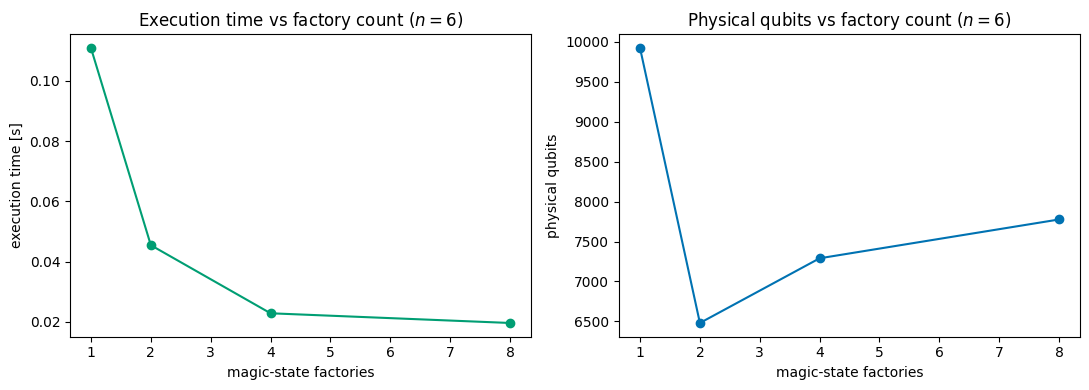

In [10]:
fig, (ax_time, ax_qubits) = plt.subplots(1, 2, figsize=(11, 4))

ax_time.plot(
    factory_df.index,
    factory_df["execution time (s)"],
    marker="o",
    color=COLOR_GREEN,
)
ax_time.set_xlabel("magic-state factories")
ax_time.set_ylabel("execution time [s]")
ax_time.set_title("Execution time vs factory count ($n = 6$)")

ax_qubits.plot(
    factory_df.index,
    factory_df["physical qubits"],
    marker="o",
    color=COLOR_BLUE,
)
ax_qubits.set_xlabel("magic-state factories")
ax_qubits.set_ylabel("physical qubits")
ax_qubits.set_title("Physical qubits vs factory count ($n = 6$)")

for ax in (ax_time, ax_qubits):
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()
plt.show()

## Pre-FTQC estimation: the STAR architecture

Between the NISQ machines of the roadmap scan and the full FTQC machines
QURATION models, the STAR architecture occupies the middle ground: it error-
corrects the Clifford operations and injects rotations non-fault-tolerantly.
We analyze the same instances — including the extended range up to $n = 14$ —
with the `star_device` model at a code distance of 9 and a physical error
rate of $10^{-4}$: the fidelity IonQ demonstrated in 2025 and superconducting
platforms are approaching.

In [11]:
from quri_parts.backend.devices import star_device

STAR_CODE_DISTANCE = 9
STAR_PHYSICAL_ERROR_RATE = 1e-4
STAR_QEC_CYCLE = TimeValue(value=1.0, unit=TimeUnit.MICROSECOND)

for extended_n in FTQC_QUBIT_RANGE:
    if extended_n not in AA_CIRCUITS:
        AA_CIRCUITS[extended_n] = aa_quri_parts_circuit(extended_n)


def star_estimate(qubit_count: int) -> dict[str, Any]:
    """Analyze one AA instance on the STAR (early-FTQC) architecture."""
    circuit = AA_CIRCUITS[qubit_count]
    prop = star_device.generate_device_property(
        qubit_count=circuit.qubit_count,
        code_distance=STAR_CODE_DISTANCE,
        qec_cycle=STAR_QEC_CYCLE,
        physical_error_rate=STAR_PHYSICAL_ERROR_RATE,
    )
    analysis = VM.from_device_prop(prop).analyze(circuit)
    latency_sec = analysis.latency.value * 1e-9  # AnalyzeResult reports ns
    return {
        "n": qubit_count,
        "logical qubits": circuit.qubit_count,
        "physical qubits": prop.physical_qubit_count,
        "fidelity": analysis.fidelity,
        "latency (s)": latency_sec,
    }


star_df = pd.DataFrame([star_estimate(n) for n in FTQC_QUBIT_RANGE]).set_index("n")
star_df.round(4)

,logical qubits,physical qubits,fidelity,latency (s)
n,,,,
3,3,1944,0.9992,0.0018
4,6,3888,0.9953,0.0070
5,8,5184,0.9905,0.0131
6,10,6480,0.9808,0.0252
7,12,7776,0.9678,0.0411
8,14,9072,0.9420,0.0728
9,16,10368,0.9049,0.1191
10,18,11664,0.8435,0.1985
11,20,12960,0.7623,0.3106


The original instances ($n \le 7$) pass comfortably (fidelity ≥ 0.96) within
~8,000 physical qubits. Over the extended range the fidelity decays steadily —
STAR's rotation injection leaves a residual, non-correctable error per
non-Clifford operation, and the T-count doubles per $+2$ in $n$ — so at a
fixed code distance the architecture eventually runs out near the top of the
range. That decay profile is the quantitative version of "early-FTQC": far
beyond NISQ, but bounded, with the remedy (a larger code distance, more
physical qubits) being exactly what full FTQC provides.

## The combined picture: one timeline from NISQ to FTQC

Finally we place the error-corrected estimates onto the NISQ roadmap
timeline. The year placement uses the vendors' *scale* milestones — IonQ
targets ~10k physical qubits in 2027 and IBM's fault-tolerant Starling
arrives in 2029 — combined with the error rates the architectures assume
(STAR's $p = 10^{-4}$ matches IonQ's demonstrated fidelity; the QURATION
estimate used $p = 10^{-3}$). The STAR requirement at its feasibility edge
(≈13k physical qubits) slightly exceeds the ~10k milestone, so the 2027
placement rounds up. These placements are indicative, not vendor
commitments.

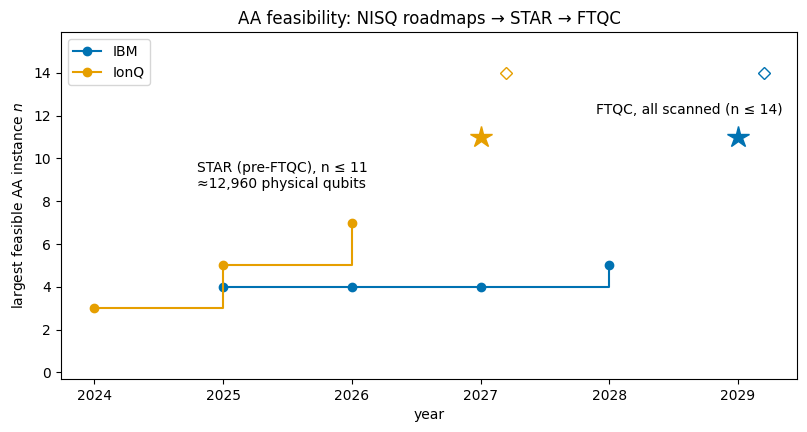

In [12]:
star_feasible = star_df.index[star_df["fidelity"] >= FEASIBILITY_THRESHOLD]
star_max_n = int(star_feasible.max())
star_physical_qubits = int(star_df.loc[star_max_n, "physical qubits"])
ftqc_max_n = max(FTQC_QUBIT_RANGE)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
plot_feasibility_timeline(ax)

# Pre-FTQC (STAR) at p = 1e-4; vendor roadmaps reach the required scale
# around 2027 (IonQ) / 2029 (IBM).
ax.plot([2027], [star_max_n], marker="*", ms=16, ls="none", color=COLOR_ORANGE)
ax.plot([2029], [star_max_n], marker="*", ms=16, ls="none", color=COLOR_BLUE)
ax.annotate(
    f"STAR (pre-FTQC), n ≤ {star_max_n}\n≈{star_physical_qubits:,} physical qubits",
    (2027, star_max_n),
    (2024.8, star_max_n - 2.4),
)

# Full FTQC: logical-qubit machines (IonQ 2027, IBM Starling 2029) dwarf the
# logical cost of every scanned instance.
ax.plot([2027.2], [ftqc_max_n], marker="D", mfc="none", ls="none", color=COLOR_ORANGE)
ax.plot([2029.2], [ftqc_max_n], marker="D", mfc="none", ls="none", color=COLOR_BLUE)
ax.annotate(
    f"FTQC, all scanned (n ≤ {ftqc_max_n})",
    (2029.2, ftqc_max_n),
    (2027.9, ftqc_max_n - 1.9),
)

ax.set_ylim(-0.3, ftqc_max_n + 1.9)
ax.set_title("AA feasibility: NISQ roadmaps → STAR → FTQC")
ax.legend(loc="upper left")
plt.show()

The three regimes tell one coherent story:

* **NISQ (now–2028)**: feasibility is fidelity-limited and ends around
  $n \approx 4$–$5$, except on IonQ's 99.99%-fidelity 2026 system, which
  reaches all instances scanned here at ~0.1 s per shot.
* **Pre-FTQC (STAR, ≈2027–2029 hardware scale)**: error-corrected Cliffords
  extend feasibility well past every NISQ machine at fixed hardware quality,
  until the residual rotation error catches up near the top of the extended
  range.
* **FTQC (2029+)**: the QURATION schedule prices the $n = 14$ instance at
  ~36k physical qubits and ~1.6 s at $p = 10^{-3}$ — modest for Starling-
  class machines (200 logical qubits, 100M gates), at which point problem
  sizes far beyond this notebook become the accessible ones.

## Beyond fidelity: time to solution

Fidelity alone hides the speed axis. A shot that fails is not wasted forever —
Grover outputs are cheap to *verify* (evaluate the oracle condition on the
measured bitstring classically), so a machine can simply repeat until a
verified hit. The metric that combines quality and speed is the **expected
time to a verified solution**:

$$
T_{\text{sol}} \;=\; \frac{t_{\text{shot}}}{F \cdot p_{\text{alg}}}
$$

where $t_{\text{shot}}$ is the circuit latency, $F$ the estimated fidelity,
and $p_{\text{alg}} = \sin^2\!\big((2k+1)\,\theta\big)$ with
$\theta = \arcsin(2^{-n/2})$ is the *algorithmic* success probability of
Grover search at $k$ iterations (close to, but not exactly, 1). The bias direction is ambiguous —
erroneous shots can still land on the marked string (an overestimate of the
time), while per-shot overheads such as reset and classical processing are
ignored (an underestimate) — but it makes platform trade-offs visible: low fidelity can be
bought back with repetitions, at the price of the platform's shot time.

In [13]:
from math import asin, sin

QURATION_FAILURE_PROB = 1e-2  # allowed_failure_prob used in the QURATION scan


def algorithm_success_probability(qubit_count: int) -> float:
    """Success probability of Grover search at the optimal iteration count."""
    theta = asin(2 ** (-qubit_count / 2))
    return sin((2 * optimal_iterations(qubit_count) + 1) * theta) ** 2


def time_to_solution(shot_time_sec: float, fidelity: float, qubit_count: int) -> float:
    """Expected wall-clock time until one verified Grover hit."""
    return shot_time_sec / (fidelity * algorithm_success_probability(qubit_count))


tts_rows: list[dict[str, Any]] = []
for n in FTQC_QUBIT_RANGE:
    row: dict[str, Any] = {"n": n, "p_alg": algorithm_success_probability(n)}
    for vendor, year in (("IBM", 2028), ("IonQ", 2026)):
        analysis = ANALYZE_RESULTS.get((vendor, year, n))
        if analysis is None or analysis.fidelity <= 0.0:
            # Not scanned (see the NISQ section) or fully decohered —
            # rendered as a gap, not a divergence.
            row[f"{vendor} {year}"] = float("nan")
        else:
            row[f"{vendor} {year}"] = time_to_solution(
                analysis.latency.value * 1e-9, analysis.fidelity, n
            )
    row["STAR"] = time_to_solution(
        star_df.loc[n, "latency (s)"], star_df.loc[n, "fidelity"], n
    )
    row["FTQC (QURATION)"] = time_to_solution(
        quration_df.loc[n, "execution time (s)"], 1.0 - QURATION_FAILURE_PROB, n
    )
    tts_rows.append(row)

tts_df = pd.DataFrame(tts_rows).set_index("n")
tts_df

,p_alg,IBM 2028,IonQ 2026,STAR,FTQC (QURATION)
n,,,,,
3,0.945312,0.000044,0.020158,0.001896,0.000646
4,0.961319,0.000308,0.099304,0.007309,0.004751
5,0.999182,0.001224,0.186766,0.013195,0.011619
6,0.996586,0.003139,0.380044,0.025772,0.023106
7,0.995620,NaN,0.656353,0.042621,0.038496
8,0.999947,NaN,NaN,0.077304,0.084182
9,0.999448,NaN,NaN,0.131652,0.139099
10,0.999461,NaN,NaN,0.235429,0.233648
11,0.999997,NaN,NaN,0.407500,0.367690


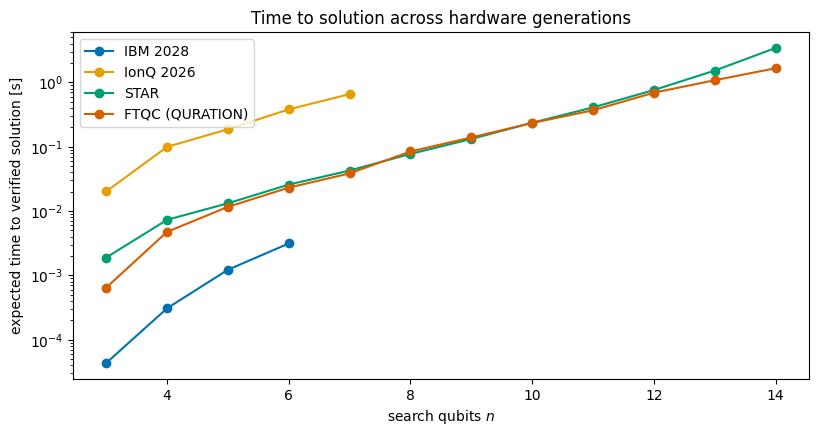

In [14]:
COLOR_VERMILLION = "#D55E00"

MACHINE_COLORS: dict[str, str] = {
    "IBM 2028": COLOR_BLUE,
    "IonQ 2026": COLOR_ORANGE,
    "STAR": COLOR_GREEN,
    "FTQC (QURATION)": COLOR_VERMILLION,
}

fig, ax = plt.subplots(figsize=(9.5, 4.5))
for machine, color in MACHINE_COLORS.items():
    ax.plot(
        tts_df.index,
        tts_df[machine],
        marker="o",
        color=color,
        label=machine,
    )
ax.set_yscale("log")
ax.set_xlabel("search qubits $n$")
ax.set_ylabel("expected time to verified solution [s]")
ax.set_title("Time to solution across hardware generations")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(loc="upper left")
plt.show()

The time axis reshuffles the ranking that fidelity alone suggested:

* **IBM's fast gates dominate at small sizes**: microsecond shots mean that
  even fidelity well below the 2/3 threshold is repaired by cheap
  repetitions. Note the IBM curve ends at $n = 6$ because larger instances
  were not scanned (routing-analysis cost), not because $T_{\text{sol}}$
  diverges there — extrapolating its fidelity trend (~0.3 at $n = 7$) would
  give a still-competitive millisecond-scale point before genuine
  divergence a step or two later.
* **IonQ's high fidelity comes with slow shots**: ~0.1 s per attempt makes
  its time-to-solution flat but high; near-unit fidelity cannot compensate
  for a $10^5\times$ slower clock at these sizes.
* **Error correction buys scaling, not speed**: STAR and the QURATION
  machine have ms-scale shots (QEC cycles are slow), so at toy sizes they are
  *slower* than NISQ — their value is visible at the right edge of the plot,
  where every NISQ curve has ended (fidelity ≈ 0 → $T_{\text{sol}} = \infty$)
  while the error-corrected curves keep tracking the circuit time out to
  $n = 14$ and beyond.

One caveat keeps this honest: repetitions preserve *correctness* for a
verifiable search, but they erode the quantum *speed-up*. Each shot costs
$k \approx \frac{\pi}{4}\sqrt{N}$ oracle calls, so the expected quantum
query count is $k/(F p_{\text{alg}})$, to be compared against $\sim N/2$
classical evaluations — at $F \ll 1$ the advantage can vanish even when
$T_{\text{sol}}$ looks acceptable. Fidelity decides *whether the speed-up
survives*; time-to-solution decides *whether the run is practical*.

## Using the qret CLI instead

The same QURATION estimation can be driven by the `qret` command-line tool
(installable with
`%pip install git+https://github.com/QunaSys/quration-cli-bundle.git`),
following the pattern of the [CNOT tutorial](basic.ipynb): dump the IR with
`module.dump(...)`, write a pipeline YAML such as

```yaml
source: IR
input: aa/aa_ir_n4.json
function: main
target: SC_LS_FIXED_V0
output: aa/compiled_aa_n4.json
sc_ls_fixed_v0_topology: aa/topology_n4_m4.yaml
sc_ls_fixed_v0_machine_type: Dim2
sc_ls_fixed_v0_physical_error_rate: 0.001
sc_ls_fixed_v0_code_cycle_time_sec: 0.000001
sc_ls_fixed_v0_allowed_failure_prob: 0.01
sc_ls_fixed_v0_drop_rate: 0.1
```

and run `qret compile --pipeline ...` followed by `qret profile`. The bundled
visualizers (`qret_cli_bundle.visualize_computational_process()` and
`visualize_compile_info()`) can then display the schedule interactively.

> **Note**: the bundled `qret` binary is built on Ubuntu 24.04 and requires
> glibc ≥ 2.38. On older Linux distributions use the `pyqret` Python API as in
> this notebook — it is functionally equivalent for compilation and resource
> estimation.

## Next steps

* Replace the marked-state oracle with a problem oracle (e.g. an arithmetic
  comparator from `pyqret.algorithm.arithmetic`).
* Wrap the Grover iterate in quantum phase estimation (`quri_algo.qsub.qpe`)
  to perform amplitude *estimation*.
* Explore the `Dim3` and `DistributedDim2` machine types and magic-state
  cultivation (`use_magic_state_cultivation=True`).
* Compare STAR against `clifford_t_device` and `abstract_ftqc_device` at the
  same gate-level granularity.